# 01: Preprocessing the PBMC 3k dataset with Python
1. Data Download
2. QC
3. Normalization
4. Dimensionality Reduction and Manifold Embedding
5. Clustering
6. DEA and Annotation

## Reference
- [Scanpy's tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html)

---
## 0. Execution Environment Summary

In [1]:
%%bash
bash .rep_exe_env_short.sh

=== Execution Start ===


Timestamp (UTC): 2026-09-29T14:24:36Z


Hostname:        hww06


OS:              Red Hat Enterprise Linux 8.8 (Ootpa)


In [2]:
ENV_SUFFIX = "c"

---
## 1. Data Download
- Downloading the PBMC3k dataset from [10x Genomics](https://www.10xgenomics.com/datasets/3-k-pbm-cs-from-a-healthy-donor-1-standard-1-1-0)'s source

In [3]:
%%bash

DATA_DIR="./data"
FILE_NAME="pbmc3k"
SRC="http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"

mkdir -p "$DATA=DIR"

if [ -f "$DATA_DIR/$FILE_NAME/matrix.mtx" ]; then
    echo "$FILE_NAME data already exists. Skipping download"
else
    wget -q $SRC -O "$DATA_DIR/$FILE_NAME.tar.gz"
    tar -xzf "$DATA_DIR/$FILE_NAME.tar.gz" -C "$DATA_DIR"
    mkdir -p "$DATA_DIR/$FILE_NAME"
    mv "$DATA_DIR/filtered_gene_bc_matrices/hg19/"* "$DATA_DIR/$FILE_NAME"
    rm -rf "$DATA_DIR/filtered_gene_bc_matrices" "$DATA_DIR/$FILE_NAME.tar.gz"
    echo "Download and extraction completed!"
fi

pbmc3k data already exists. Skipping download


---
## 2. QC
### 2-1. Thresholding QC metrics

In [4]:
import hashlib
import logging
import os
import warnings

import celltypist
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import scanpy as sc
import seaborn as sns

from basalcelldemo_tools.anndata import transfer_embedding_info
from basalcelldemo_tools.preferences import (
    DATA_DIR,
    OUTPUT_DIR,
    CellTypist_Models,
    kwarg_savefig,
)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

/hshare1/ZETTAI_path_WA_slash_home_KARA/home/yokano/OnlyPoetry/.venv/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [5]:
adata = sc.read_10x_mtx("./data/pbmc3k")

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [7]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

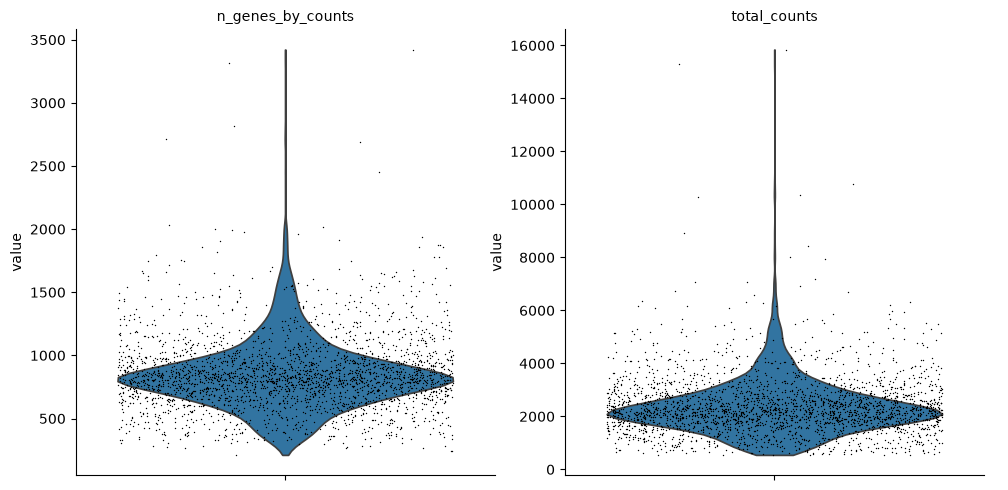

In [8]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

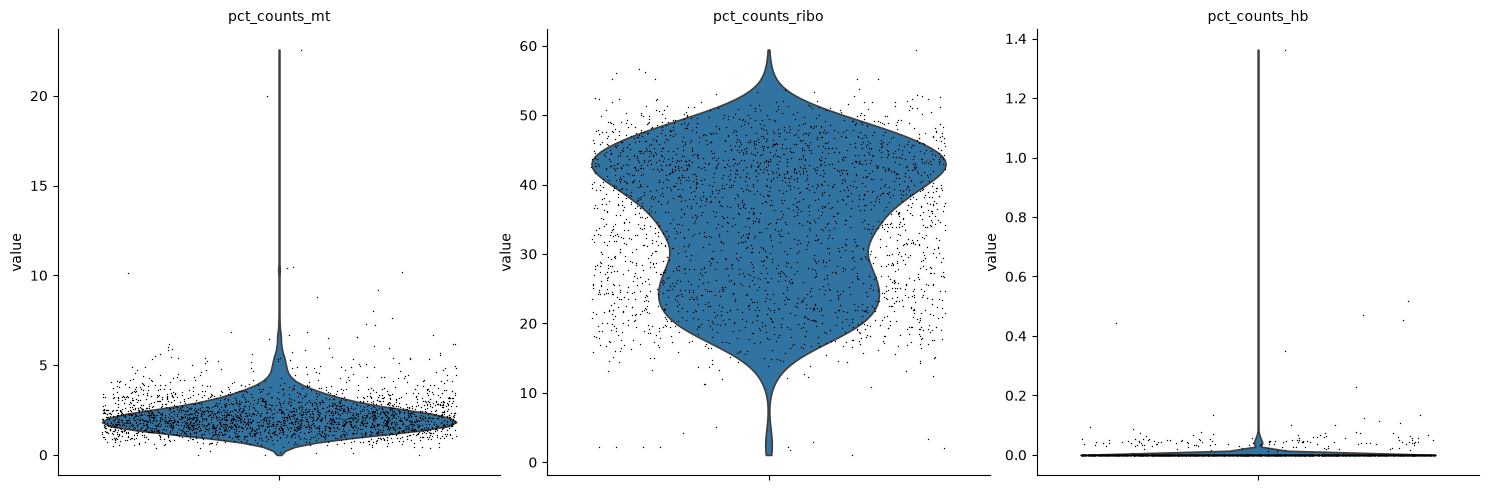

In [9]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

In [10]:
filtered_cells = (
    pl.from_pandas(adata.obs.reset_index())
    .filter(
        (500 <= pl.col("n_genes_by_counts"))
        & (pl.col("n_genes_by_counts") <= 1500)
        & (pl.col("total_counts") < 6000)
        & (pl.col("pct_counts_mt") < 5)
        & (20 < pl.col("pct_counts_ribo"))
        & (pl.col("pct_counts_ribo") < 50)
        & (pl.col("pct_counts_hb") < 0.1)
    )
    .select("index")
    .to_pandas()
    .set_index("index")
    .index
)

adata = adata[filtered_cells, :].copy()

In [11]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

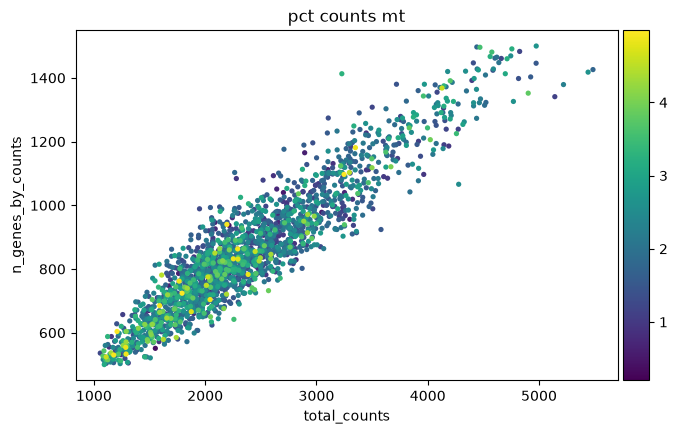

In [12]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### 2-2. Doublet Detection

In [13]:
sc.pp.scrublet(adata)

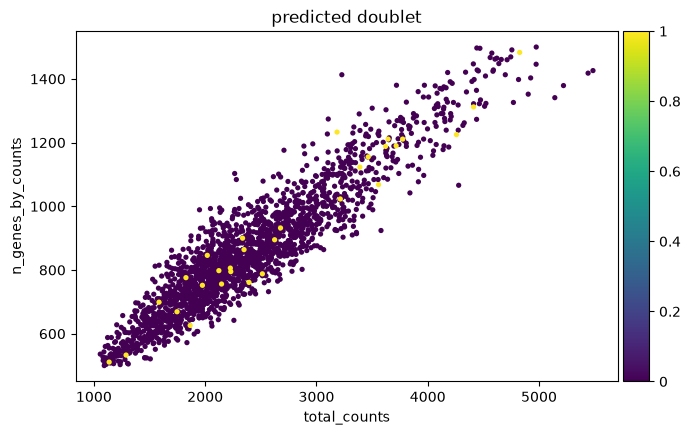

In [14]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="predicted_doublet")

In [15]:
adata = adata[~adata.obs["predicted_doublet"], :].copy()

---
## 3. Normalization

In [16]:
adata.layers["counts"] = adata.X.copy()

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

---
## 4. Dimensionality Reduction and Manifold Embedding
### 4-1. Feature Selection

In [18]:
ad_manifold = adata.copy()

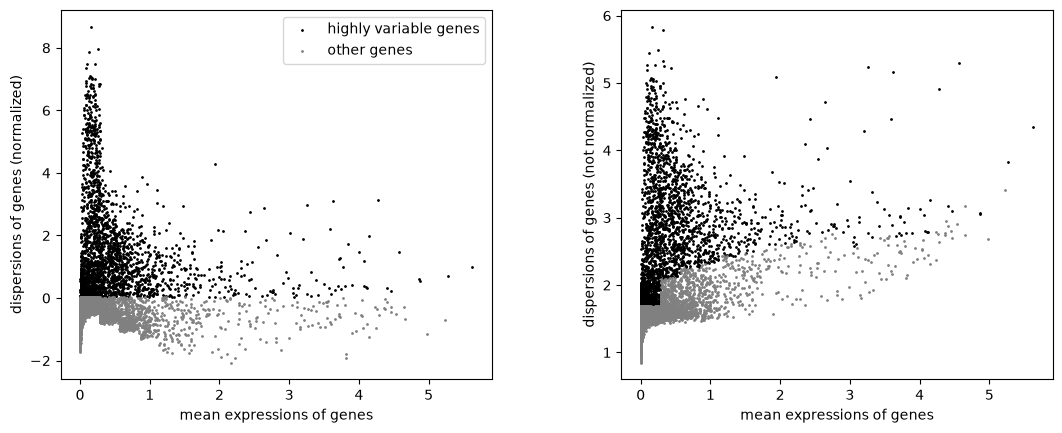

In [19]:
sc.pp.highly_variable_genes(ad_manifold, n_top_genes=3000)
sc.pl.highly_variable_genes(ad_manifold)

In [20]:
ad_manifold = ad_manifold[:, ad_manifold.var.highly_variable]

### 4-2. Dimensionality Reduction

In [21]:
sc.tl.pca(ad_manifold, svd_solver="arpack")

### 4-3. Manifold Embedding

In [22]:
sc.pp.neighbors(ad_manifold, n_pcs=50)

In [23]:
sc.tl.umap(ad_manifold)

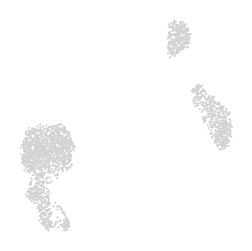

In [24]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(ad_manifold, ax=ax, size=10, show=False)
ax.axis("off");

In [25]:
transfer_embedding_info(adata_source=ad_manifold, adata_target=adata, overwrite=True)
del ad_manifold

---
## 5. Clustering

In [26]:
sc.tl.leiden(adata, resolution=1)

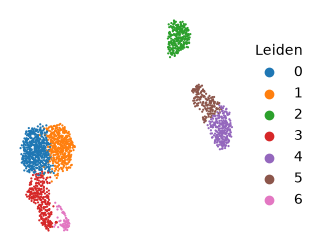

In [27]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(adata, ax=ax, size=10, show=False, color="leiden")
ax.axis("off")
ax.set(title="")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Leiden", frameon=False)

fig.savefig(OUTPUT_DIR / f"umap_{ENV_SUFFIX}.pdf", **kwarg_savefig)

---
## 6. DEA and Annotation
### 6-1. DEA

In [28]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")

In [29]:
degs = (
    pl.from_pandas(sc.get.rank_genes_groups_df(adata, group=None))
    .filter((pl.col("pvals_adj") < 0.05) & (pl.col("logfoldchanges") > 1))
    .select(pl.col("group").cast(str), "names", "logfoldchanges", "pvals_adj")
)
degs.write_parquet(DATA_DIR / f"degs_{ENV_SUFFIX}.pq")
degs

group,names,logfoldchanges,pvals_adj
str,str,f32,f64
"""0""","""LTB""",2.272123,3.8567e-85
"""0""","""IL32""",2.375396,1.3022e-73
"""0""","""LDHB""",1.738719,2.0992e-65
"""0""","""IL7R""",2.303934,6.6563e-63
"""0""","""CD3D""",1.94753,3.0324e-49
…,…,…,…
"""6""","""PTGDR""",3.548436,0.041779
"""6""","""PLEKHF1""",3.495875,0.04282
"""6""","""MSN""",1.374327,0.045105


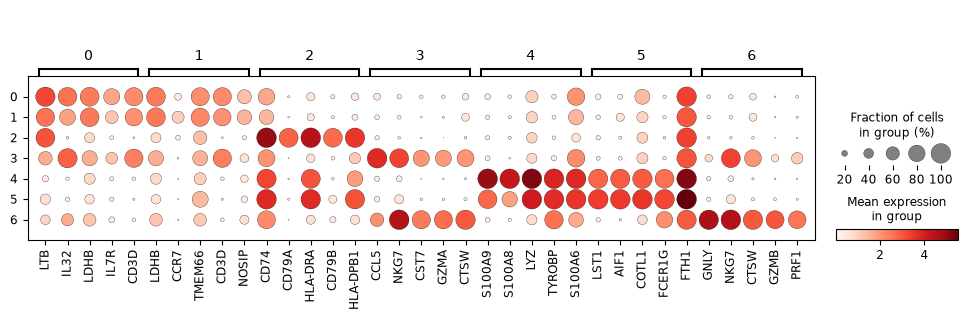

In [30]:
fig, ax = plt.subplots(figsize=(12, 3))

n_degs = 5

sc.pl.dotplot(
    adata,
    dict(
        degs.group_by("group", maintain_order=True)
        .agg(pl.col("names").head(n_degs))
        .iter_rows()
    ),
    "leiden",
    ax=ax,
)

ax.set(title=f"Top {n_degs} DEGs")

fig.savefig(OUTPUT_DIR / f"top{n_degs}degs_{ENV_SUFFIX}.pdf", **kwarg_savefig)

In [31]:
sc.get.obs_df(
    adata,
    keys=degs["names"].unique(maintain_order=True).to_numpy().tolist() + ["leiden"],
).reset_index().to_parquet(DATA_DIR / f"expressions_{ENV_SUFFIX}.pq")

In [32]:
n_degs = 10

degs.group_by("group", maintain_order=True).agg(pl.col("names").head(n_degs)).explode(
    "names"
).unique("names", maintain_order=True).with_columns(
    leiden_colors=pl.col("group").replace(
        {str(i): v for i, v in enumerate(adata.uns["leiden_colors"])}
    )
).write_parquet(DATA_DIR / f"top_degs_{ENV_SUFFIX}.pq")

### 6-2. Automated Annotation with CellTypist

In [33]:
celltypist.models.models_path = str(CellTypist_Models)

MODEL_NAME = "Immune_All_Low.pkl"
model_path = CellTypist_Models / MODEL_NAME

if not model_path.exists():
    celltypist.models.download_models(model=MODEL_NAME)

with model_path.open("rb") as f:
    print(hashlib.file_digest(f, "sha256").hexdigest())

290874d35dac039d4c9218c343fde4aac1077709b72a331ce7266f6828c36502


In [34]:
model_ct = celltypist.models.Model.load(model=MODEL_NAME)

In [35]:
sc.tl.leiden(
    adata,
    resolution=5,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    key_added="celltypist_over_clustering",
)

annotated = celltypist.annotate(
    adata,
    model=model_ct,
    majority_voting=True,
    over_clustering="celltypist_over_clustering",
).to_adata(prefix="celltypist_")

🔬 Input data has 2070 cells and 13123 genes


🔗 Matching reference genes in the model


🧬 4007 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


🗳️ Majority voting the predictions


✅ Majority voting done!


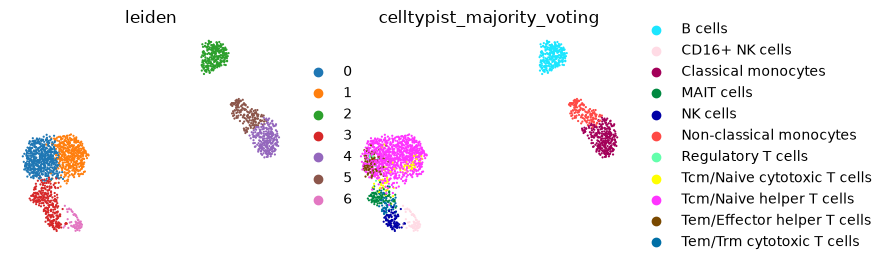

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

candidate_size = adata.obs["celltypist_majority_voting"].unique().size
candidate_colors = {
    v: mcolors.to_hex(sc.plotting.palettes.godsnot_102[i])
    for i, v in enumerate(adata.obs["celltypist_majority_voting"].unique())
}

for a, hue in zip(ax.ravel(), ["leiden", "celltypist_majority_voting"]):
    sc.pl.umap(
        annotated,
        ax=a,
        size=10,
        show=False,
        color=hue,
        palette=adata.uns["leiden_colors"] if hue == "leiden" else candidate_colors,
    )
    a.axis("off")

    a.set_aspect("equal")
    a.set(title=hue)
    a.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

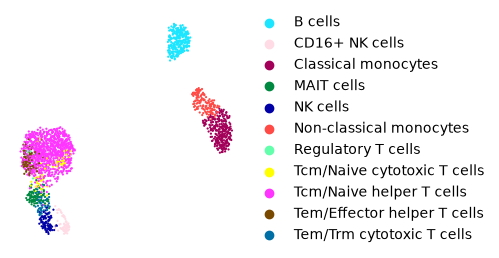

In [37]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(
    adata,
    color="celltypist_majority_voting",
    ax=ax,
    size=10,
    show=False,
    palette=candidate_colors,
)

ax.axis("off")

ax.set(title="")
a.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, title="CellTypist")

fig.savefig(OUTPUT_DIR / f"umap_celltypist_{ENV_SUFFIX}.pdf", **kwarg_savefig)

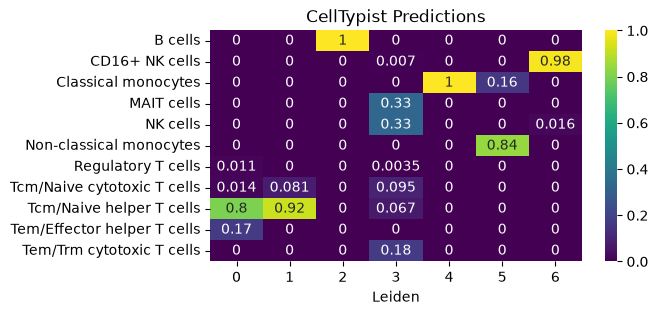

In [38]:
fig, ax = plt.subplots(figsize=(6, 3))

df_ct = pd.crosstab(
    annotated.obs["leiden"], annotated.obs["celltypist_majority_voting"]
)

sns.heatmap(data=(df_ct.T / df_ct.sum(axis=1)), cmap="viridis", ax=ax, annot=True)

ax.set(title="CellTypist Predictions", xlabel="Leiden", ylabel="")

fig.savefig(OUTPUT_DIR / f"celltypist_{ENV_SUFFIX}.pdf", **kwarg_savefig)

In [39]:
df_obs = pl.DataFrame(annotated.obs[["leiden", "celltypist_majority_voting"]])

mapping_df = (
    df_obs.group_by("leiden", maintain_order=True)
    .agg(pl.col("celltypist_majority_voting").mode().first().alias("ct"))
    .cast(pl.String)
    .sort("leiden")
    .with_columns(
        annotation=pl.when(pl.len().over("ct") > 1)
        .then(
            pl.col("ct")
            + " #"
            + pl.int_range(1, pl.len() + 1).over("ct").cast(pl.String)
        )
        .otherwise(pl.col("ct"))
    )
    .select("leiden", "annotation")
)

mapping_df

leiden,annotation
str,str
"""0""","""Tcm/Naive helper T cells #1"""
"""1""","""Tcm/Naive helper T cells #2"""
"""2""","""B cells"""
"""3""","""NK cells"""
"""4""","""Classical monocytes"""
"""5""","""Non-classical monocytes"""
"""6""","""CD16+ NK cells"""


In [40]:
adata.obs["annotation"] = adata.obs["leiden"].map(
    dict(zip(mapping_df["leiden"], mapping_df["annotation"]))
)

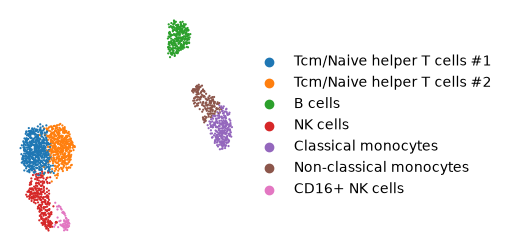

In [41]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(
    adata,
    color="annotation",
    ax=ax,
    size=10,
    show=False,
    palette=adata.uns["leiden_colors"],
)

ax.axis("off")

ax.set(title="")
a.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, title="Annotation")

fig.savefig(OUTPUT_DIR / f"umap_with_annotation_{ENV_SUFFIX}.pdf", **kwarg_savefig)

In [42]:
pl.from_pandas(
    adata.obs[["leiden", "celltypist_majority_voting", "annotation"]]
    .astype(str)
    .reset_index()
).with_columns(
    leiden_colors=pl.col("leiden").replace(
        {str(i): v for i, v in enumerate(adata.uns["leiden_colors"])}
    )
).with_columns(
    celltypist_colors=pl.col("celltypist_majority_voting").replace(candidate_colors)
).write_parquet(DATA_DIR / f"annotations_{ENV_SUFFIX}.pq")

---
## 7. Execution Environment Details

In [43]:
%%bash
bash .rep_exe_env.sh

Execution Environment

Timestamp (UTC):         2026-09-29T14:26:39Z


Hostname:                hww06


FQDN:                    hww06i


OS:                      Red Hat Enterprise Linux 8.8 (Ootpa)


...

Cores / socket:          24
Threads / core:          1
Logical CPUs:            48


System memory:           1006.9 GiB


System vendor:           XFUSION


System model:            2288H V7


GPU(s):                  None / nvidia-smi unavailable
